# Chapter 9: Target Encoding Without Leakage

**How far does each target-encoding pipeline's cross-validation estimate drift from its score on new rows?**

Target encoding is one of the most common sources of a validation score that does not survive the leaderboard. Measuring the gap tells you which shortcut is safe and which one quietly rewards a leak.

*Constructed data; the effect sizes are properties of this generator, not a competition result.*

## The experiment

A constructed binary task with 300 categories of 2 to 9 training rows each, two numeric features, and a true category effect whose size is the control. Each pipeline encodes the category with the chapter's smoothed mean (m = 10), fits a logistic regression and is scored two ways: 5-fold cross-validation on the 1,606 training rows, and AUC on 4,000 new rows from the same generator.

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

from kaggle_companion.activities._common import clean

SEED = 9
M = 10.0  # smoothing strength from the chapter's smoothed mean


def generate(category_signal, seed=SEED):
    """Training rows and a large holdout. 300 categories with 2 to 9 training rows each."""
    rng = np.random.default_rng(seed)
    n_cat = 300
    effect = rng.normal(0.0, category_signal, n_cat)          # true category effect (log odds)
    counts = rng.integers(2, 10, n_cat)
    cat_train = np.repeat(np.arange(n_cat), counts)
    cat_hold = rng.integers(0, n_cat, 4000)

    def rows(cat):
        x = rng.normal(size=(len(cat), 2))
        logit = 0.8 * x[:, 0] - 0.5 * x[:, 1] + effect[cat] - 0.3
        y = (rng.random(len(cat)) < 1 / (1 + np.exp(-logit))).astype(int)
        return x, y

    x_train, y_train = rows(cat_train)
    x_hold, y_hold = rows(cat_hold)
    return cat_train, x_train, y_train, cat_hold, x_hold, y_hold


def smoothed_map(cat, y, n_cat=300):
    """Training-only smoothed mean e_c = (s_c + m*mu) / (n_c + m)."""
    mu = y.mean()
    s = np.bincount(cat, weights=y, minlength=n_cat)
    n = np.bincount(cat, minlength=n_cat)
    return (s + M * mu) / (n + M)


def oof_encode(cat, y, seed):
    """Cross-fitted encoding: each row is encoded from the other folds only."""
    enc = np.zeros(len(cat))
    for fit, out in KFold(5, shuffle=True, random_state=seed).split(cat):
        enc[out] = smoothed_map(cat[fit], y[fit])[cat[out]]
    return enc


def fit_score(x_fit, enc_fit, y_fit, x_eval, enc_eval, y_eval):
    model = LogisticRegression(max_iter=1000).fit(np.column_stack([x_fit, enc_fit]), y_fit)
    return roc_auc_score(y_eval, model.predict_proba(np.column_stack([x_eval, enc_eval]))[:, 1])


def run(category_signal):
    cat, x, y, cat_h, x_h, y_h = generate(category_signal)
    outer = list(KFold(5, shuffle=True, random_state=1).split(cat))
    full_map = smoothed_map(cat, y)

    # 1. Naive: one encoding from all training labels, each row's own label included.
    naive_col = full_map[cat]
    naive_cv = np.mean([fit_score(x[a], naive_col[a], y[a], x[b], naive_col[b], y[b]) for a, b in outer])
    naive_hold = fit_score(x, naive_col, y, x_h, full_map[cat_h], y_h)

    # 2. Global OOF table: cross-fitted once, then model CV on that table (fails the second boundary).
    oof_col = oof_encode(cat, y, seed=2)
    global_cv = np.mean([fit_score(x[a], oof_col[a], y[a], x[b], oof_col[b], y[b]) for a, b in outer])

    # 3. Nested: inside each outer fold, cross-fit the training rows and map the validation rows.
    nested_scores = []
    for a, b in outer:
        enc_a = oof_encode(cat[a], y[a], seed=3)
        enc_b = smoothed_map(cat[a], y[a])[cat[b]]
        nested_scores.append(fit_score(x[a], enc_a, y[a], x[b], enc_b, y[b]))
    nested_cv = np.mean(nested_scores)

    # The deployable pipeline for 2 and 3 is the same: cross-fitted training column, full map for new rows.
    honest_hold = fit_score(x, oof_col, y, x_h, full_map[cat_h], y_h)
    no_enc_hold = roc_auc_score(y_h, LogisticRegression(max_iter=1000).fit(x, y).predict_proba(x_h)[:, 1])

    return clean({
        "category_signal": category_signal,
        "naive": {"cv": naive_cv, "holdout": naive_hold},
        "global_oof": {"cv": global_cv, "holdout": honest_hold},
        "nested": {"cv": nested_cv, "holdout": honest_hold},
        "no_encoding_holdout": no_enc_hold,
        "training_rows": len(y), "categories": 300,
    })


## Measure it across the control

The control is **true category effect (standard deviation, log odds)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch09 import explain

VALUES = [0, 0.5, 1.0, 1.5]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                              0    0.5    1.0    1.5
Naive CV estimate         0.791  0.804  0.846  0.879
Naive on new rows         0.690  0.694  0.733  0.773
Nested CV estimate        0.728  0.711  0.727  0.764
Cross-fitted on new rows  0.717  0.713  0.735  0.772
No encoding on new rows   0.718  0.710  0.692  0.666


## Look at it

The figure shows the default setting, true category effect (standard deviation, log odds) = 1.0.

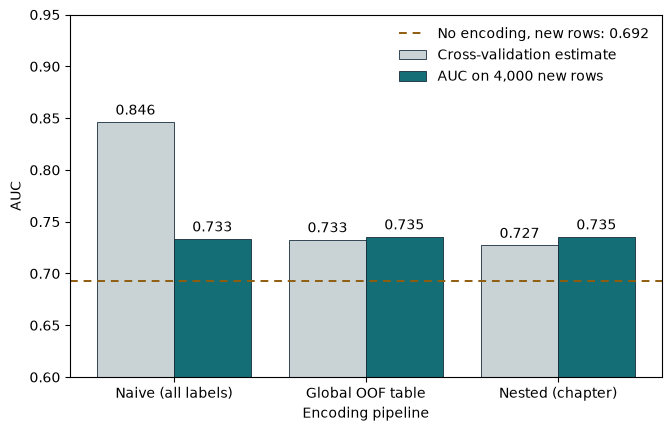

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch09 import draw, NCOLS, HEIGHT

DEFAULT = 1.0
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

At category effect 1.0: the naive pipeline reports 0.846 but scores 0.733 on new rows, 0.846 - 0.733 = 0.113 of optimism. The nested estimate 0.727 is 0.008 from its new-row score 0.735; the global OOF table reports 0.733. Compared with no encoding, the encoded column adds 0.043 AUC on new rows.

- Naive: 0.846 - 0.733 = 0.113 (estimate minus new rows).
- Global OOF table: 0.733 - 0.735 = -0.003.
- Nested: 0.727 - 0.735 = -0.008.
- Value of the encoding on new rows: 0.735 - 0.692 = +0.043.

## Apply this to your competition

- Wrap the encoder in the same outer folds as the model; never encode the full training set once and then cross-validate.
- Inside each outer fold, cross-fit the training rows and map validation rows with a map fitted on outer-training labels only.
- Always compare against the model without the encoded column: an encoding that adds nothing is a cost, not a feature.
- Choose the smoothing strength m with inner validation, not by habit.

Book location: Chapter 9, Two Boundaries, Not One Global OOF Table.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)